# mFam × MassBank chemical space and novelty

This notebook **recomputes** the chemical-space embedding and novelty metrics used for Figure 3 in the manuscript "The MassBank contributions of the mFam Collaboration" from two input tables:

- `MassBank_master_with_smiles.tsv` (MassBank release, e.g. 2025.05.1)
- `mFam_master_raw.csv` (mFam contributions)

It then generates the three Figure 3 panels:
- **(a)** UMAP of ECFP4 fingerprints (MassBank vs mFam) with highlighted most novel mFam structures  
- **(b)** Nearest-neighbor similarity distribution (excluding near-identical matches, similarity ≥ 0.99)  
- **(c)** Structures of the top-N most structurally distinct mFam compounds (deduplicated by normalized SMILES)


In [1]:
# --- Imports ---
import os
import numpy as np
import pandas as pd

from rdkit import Chem
from rdkit.Chem import AllChem, Draw, Descriptors
from rdkit import DataStructs

import umap
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- Style ---
plt.rcParams.update({
    "font.size": 12,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
})

COL_BASELINE = "#BDBDBD"   # MassBank grey
COL_MFAM     = "#2C5AA0"   # mFam blue


/lustre/BIF/nobackup/charr003/miniforge3/envs/lattice_flash/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- Input paths ---
MASSBANK_PATH = "/lustre/BIF/nobackup/charr003/projects/PostDoc/mFam-contributions/data/MassBank_master_with_smiles.tsv"
MFAM_PATH     = "/lustre/BIF/nobackup/charr003/projects/PostDoc/mFam-contributions/data/mFam_master_raw.csv"

# --- Output paths ---
OUT_DIR = "./../results"
import os; os.makedirs(OUT_DIR, exist_ok=True)

OUT_COMBINED_TSV = os.path.join(OUT_DIR, "Chemoexplorer_combined_with_novelty.tsv")
OUT_FIG3A = os.path.join(OUT_DIR, "Fig3a_UMAP.png")
OUT_FIG3B = os.path.join(OUT_DIR, "Fig3b_similarity_hist.png")
OUT_FIG3C_PNG = os.path.join(OUT_DIR, "Fig3c_topN_structures.png")
OUT_FIG3C_SVG = os.path.join(OUT_DIR, "Fig3c_topN_structures.svg")

TOP_N_PER_LAB    = 10   # top-N novel compounds per lab (Fig 3a highlight)
TOP_N_LABS       = 5    # number of labs featured in Fig 3c
TOP_N_PER_LAB_FIG3C = 4  # structures per lab in Fig 3c
NEAR_IDENTICAL_THRESHOLD = 0.99

# UMAP parameters
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
UMAP_RANDOM_STATE = 42


## 1) Load input tables

This notebook is robust to minor column naming differences. It looks for a SMILES column among:
`smiles_norm`, `smiles`, `smiles_raw`, `CH$SMILES`, `SMILES`.

Required columns after harmonization:
- `accession`
- `smiles_raw` (input smiles)
- `source` (`MassBank_2025.05.1` or `mFam`)


In [3]:
def _find_first_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def _looks_like_accession(x: str) -> bool:
    if not isinstance(x, str):
        return False
    # MassBank accessions look like "MB000001" or "MSBNK-..."
    return x.startswith("MB") or x.startswith("MSBNK")

def load_massbank(path):
    # Try headered read first
    df = pd.read_csv(path, sep="\t", dtype=str)
    if "accession" not in df.columns:
        # Headerless TSV
        df = pd.read_csv(path, sep="\t", header=None, dtype=str)
        if df.shape[1] >= 4:
            df.columns = ["accession","smiles_raw","name","ion_mode"] + [f"extra_{i}" for i in range(df.shape[1]-4)]
        elif df.shape[1] == 2:
            df.columns = ["accession","smiles_raw"]
        else:
            raise ValueError(f"Unexpected number of columns in {path}: {df.shape[1]}")
    else:
        # Standardize names if needed
        acc_col = _find_first_col(df, ["accession","ACCESSION","Accession","id"])
        if acc_col != "accession":
            df = df.rename(columns={acc_col: "accession"})
        smi_col = _find_first_col(df, ["smiles_norm","smiles","smiles_raw","CH$SMILES","SMILES"])
        if smi_col is None:
            raise ValueError("Could not find a SMILES column in MassBank table.")
        if smi_col != "smiles_raw":
            df = df.rename(columns={smi_col: "smiles_raw"})
        name_col = _find_first_col(df, ["name","CH$NAME","NAME"])
        if name_col and name_col != "name":
            df = df.rename(columns={name_col: "name"})
        ion_col = _find_first_col(df, ["ion_mode","ION_MODE"])
        if ion_col and ion_col != "ion_mode":
            df = df.rename(columns={ion_col: "ion_mode"})
    df["source"] = "MassBank_2025.05.1"
    keep = [c for c in ["accession","smiles_raw","name","ion_mode","source"] if c in df.columns]
    return df[keep].copy()

def load_mfam(path):
    if path.endswith(".tsv"):
        df = pd.read_csv(path, sep="\t", dtype=str)
    else:
        df = pd.read_csv(path, dtype=str)

    if "accession" not in df.columns:
        if path.endswith(".tsv"):
            df = pd.read_csv(path, sep="\t", header=None, dtype=str)
        else:
            df = pd.read_csv(path, header=None, dtype=str)
        if df.shape[1] >= 4:
            df.columns = ["accession","smiles_raw","name","ion_mode"] + [f"extra_{i}" for i in range(df.shape[1]-4)]
        elif df.shape[1] == 2:
            df.columns = ["accession","smiles_raw"]
        else:
            raise ValueError(f"Unexpected number of columns in {path}: {df.shape[1]}")
    else:
        acc_col = _find_first_col(df, ["accession","ACCESSION","Accession","id"])
        if acc_col != "accession":
            df = df.rename(columns={acc_col: "accession"})
        smi_col = _find_first_col(df, ["smiles_norm","smiles","smiles_raw","CH$SMILES","SMILES"])
        if smi_col is None:
            raise ValueError("Could not find a SMILES column in mFam table.")
        if smi_col != "smiles_raw":
            df = df.rename(columns={smi_col: "smiles_raw"})
        name_col = _find_first_col(df, ["name","CH$NAME","NAME"])
        if name_col and name_col != "name":
            df = df.rename(columns={name_col: "name"})
        ion_col = _find_first_col(df, ["ion_mode","ION_MODE"])
        if ion_col and ion_col != "ion_mode":
            df = df.rename(columns={ion_col: "ion_mode"})
    df["source"] = "mFam"
    keep = [c for c in ["accession","smiles_raw","name","ion_mode","source"] if c in df.columns]
    return df[keep].copy()

massbank = load_massbank(MASSBANK_PATH)
mfam = load_mfam(MFAM_PATH)

print("MassBank rows:", len(massbank))
print("mFam rows:", len(mfam))
print("MassBank columns:", list(massbank.columns))
print("mFam columns:", list(mfam.columns))
massbank.head()


MassBank rows: 123817
mFam rows: 7872
MassBank columns: ['accession', 'smiles_raw', 'name', 'ion_mode', 'source']
mFam columns: ['accession', 'smiles_raw', 'name', 'ion_mode', 'source']


,accession,smiles_raw,name,ion_mode,source
0,MSBNK-Literature_Specs-LIT00007,O=C(CCCCCCCCCCCCC)N(CCO)CCO,C13DEA,ION_MODE POSITIVE,MassBank_2025.05.1
1,MSBNK-Literature_Specs-LIT00008,O=C(CCCCCCCCCCC)N(CCO)CCO,C11DEA,ION_MODE POSITIVE,MassBank_2025.05.1
2,MSBNK-Literature_Specs-LIT00030,O=C(OC)CCCCCCCCc1ccc(OCCOCC(=O)OC)cc1,CA8PE2C,ION_MODE POSITIVE,MassBank_2025.05.1
3,MSBNK-Literature_Specs-LIT00023,O=C(O)CC(CCCC)COCCOCCOCC(=O)O,1COOH-2But-A7EO2-OCH2COOH,ION_MODE POSITIVE,MassBank_2025.05.1
4,MSBNK-Literature_Specs-LIT00024,OC(=O)COCCOCC(CC(=O)O)CCCC,1COOH-2But-A7EO1-OCH2COOH,ION_MODE POSITIVE,MassBank_2025.05.1


## 2) Normalize SMILES and compute ECFP4 fingerprints

We canonicalize SMILES using RDKit (`MolToSmiles(..., canonical=True)`).
This is used for deduplication and for structure panels.


In [4]:
def normalize_smiles(s):
    if not isinstance(s, str) or not s.strip():
        return None
    m = Chem.MolFromSmiles(s)
    if m is None:
        return None
    return Chem.MolToSmiles(m, canonical=True)

def smiles_to_mol(s_norm):
    if not isinstance(s_norm, str) or not s_norm.strip():
        return None
    return Chem.MolFromSmiles(s_norm)

def mol_to_ecfp4(mol, nbits=2048, radius=2):
    if mol is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nbits)

df = pd.concat([massbank, mfam], ignore_index=True)

df["smiles_norm"] = df["smiles_raw"].map(normalize_smiles)
df["mol"] = df["smiles_norm"].map(smiles_to_mol)

valid = df["mol"].notna()
print("Valid molecules:", int(valid.sum()), "/", len(df))

# Fingerprints for valid molecules only
df_valid = df.loc[valid].copy()
df_valid["fp"] = df_valid["mol"].map(mol_to_ecfp4)

df_valid.head()


[10:35:08] Can't kekulize mol.  Unkekulized atoms: 2 4 6


Valid molecules: 130639 / 131689


[10:36:00] DEPRECATION WARNING: please use MorganGenerator
[10:36:00] DEPRECATION WARNING: please use MorganGenerator
[10:36:00] DEPRECATION WARNING: please use MorganGenerator
[10:36:00] DEPRECATION WARNING: please use MorganGenerator
[10:36:00] DEPRECATION WARNING: please use MorganGenerator
[10:36:00] DEPRECATION WARNING: please use MorganGenerator
[10:36:00] DEPRECATION WARNING: please use MorganGenerator
[10:36:00] DEPRECATION WARNING: please use MorganGenerator
[10:36:00] DEPRECATION WARNING: please use MorganGenerator
[10:36:00] DEPRECATION WARNING: please use MorganGenerator
[10:36:00] DEPRECATION WARNING: please use MorganGenerator
[10:36:00] DEPRECATION WARNING: please use MorganGenerator
[10:36:00] DEPRECATION WARNING: please use MorganGenerator
[10:36:00] DEPRECATION WARNING: please use MorganGenerator
[10:36:00] DEPRECATION WARNING: please use MorganGenerator
[10:36:00] DEPRECATION WARNING: please use MorganGenerator
[10:36:00] DEPRECATION WARNING: please use MorganGenerat

,accession,smiles_raw,name,ion_mode,source,smiles_norm,mol,fp
0,MSBNK-Literature_Specs-LIT00007,O=C(CCCCCCCCCCCCC)N(CCO)CCO,C13DEA,ION_MODE POSITIVE,MassBank_2025.05.1,CCCCCCCCCCCCCC(=O)N(CCO)CCO,<rdkit.Chem.rdchem.Mol object at 0x7fd3e0307060>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,MSBNK-Literature_Specs-LIT00008,O=C(CCCCCCCCCCC)N(CCO)CCO,C11DEA,ION_MODE POSITIVE,MassBank_2025.05.1,CCCCCCCCCCCC(=O)N(CCO)CCO,<rdkit.Chem.rdchem.Mol object at 0x7fd3df274eb0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,MSBNK-Literature_Specs-LIT00030,O=C(OC)CCCCCCCCc1ccc(OCCOCC(=O)OC)cc1,CA8PE2C,ION_MODE POSITIVE,MassBank_2025.05.1,COC(=O)CCCCCCCCc1ccc(OCCOCC(=O)OC)cc1,<rdkit.Chem.rdchem.Mol object at 0x7fd3df274f20>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, ..."
3,MSBNK-Literature_Specs-LIT00023,O=C(O)CC(CCCC)COCCOCCOCC(=O)O,1COOH-2But-A7EO2-OCH2COOH,ION_MODE POSITIVE,MassBank_2025.05.1,CCCCC(COCCOCCOCC(=O)O)CC(=O)O,<rdkit.Chem.rdchem.Mol object at 0x7fd3df274f90>,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
4,MSBNK-Literature_Specs-LIT00024,OC(=O)COCCOCC(CC(=O)O)CCCC,1COOH-2But-A7EO1-OCH2COOH,ION_MODE POSITIVE,MassBank_2025.05.1,CCCCC(COCCOCC(=O)O)CC(=O)O,<rdkit.Chem.rdchem.Mol object at 0x7fd3df275000>,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."


## 3) UMAP embedding
UMAP is fit on the combined set (MassBank baseline + mFam).


In [5]:
# Convert RDKit bit vectors -> numpy boolean array for UMAP
def fps_to_numpy(fps):
    n = len(fps)
    nbits = fps[0].GetNumBits()
    X = np.zeros((n, nbits), dtype=np.uint8)
    for i, fp in enumerate(fps):
        arr = np.zeros((nbits,), dtype=np.int8)
        DataStructs.ConvertToNumpyArray(fp, arr)
        X[i, :] = arr
    return X

fps = list(df_valid["fp"].values)
X = fps_to_numpy(fps)

reducer = umap.UMAP(
    n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    n_components=2,
    metric="jaccard",
    random_state=UMAP_RANDOM_STATE,
    verbose=True
)

Z = reducer.fit_transform(X)
df_valid["UMAP1"] = Z[:, 0]
df_valid["UMAP2"] = Z[:, 1]

df_valid[["UMAP1","UMAP2"]].describe()


/lustre/BIF/nobackup/charr003/miniforge3/envs/lattice_flash/lib/python3.12/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/lustre/BIF/nobackup/charr003/miniforge3/envs/lattice_flash/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(angular_rp_forest=True, metric='jaccard', n_jobs=1, random_state=42, verbose=True)
Wed Apr 29 10:36:22 2026 Construct fuzzy simplicial set
Wed Apr 29 10:36:23 2026 Finding Nearest Neighbors
Wed Apr 29 10:36:23 2026 Building RP forest with 23 trees
Wed Apr 29 10:37:09 2026 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	 3  /  17
	 4  /  17
	Stopping threshold met -- exiting after 4 iterations
Wed Apr 29 10:37:45 2026 Finished Nearest Neighbor Search
Wed Apr 29 10:37:50 2026 Construct embedding


Epochs completed:   0%|            1/200 [00:04]

	completed  0  /  200 epochs


Epochs completed:  10%| █          21/200 [01:38]

...

Epochs completed:  90%| █████████  181/200 [17:50]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [19:58]


Wed Apr 29 11:27:34 2026 Finished embedding


,UMAP1,UMAP2
count,130639.000000,130639.000000
mean,3.706225,3.265888
std,10.953253,10.740583
min,-21.059132,-21.572884
25%,-4.591947,-4.764492
50%,4.166474,3.544864
75%,11.606194,11.053022
max,28.965624,27.984005


## 4) Nearest-neighbor similarity

For each mFam compound we compute the **maximum** Tanimoto similarity to any compound in MassBank.
This quantifies structural novelty relative to the earlier release.


In [6]:
old = df_valid[df_valid["source"] == "MassBank_2025.05.1"].copy()
mf  = df_valid[df_valid["source"] == "mFam"].copy()

old_fps = list(old["fp"].values)
mf_fps  = list(mf["fp"].values)

print("Baseline (MassBank) valid:", len(old_fps))
print("mFam valid:", len(mf_fps))

def max_tanimoto_to_reference(query_fps, ref_fps, chunk_size=5000):
    max_sims = np.zeros(len(query_fps), dtype=np.float32)
    for start in range(0, len(ref_fps), chunk_size):
        ref_chunk = ref_fps[start:start+chunk_size]
        for i, q in enumerate(query_fps):
            sims = DataStructs.BulkTanimotoSimilarity(q, ref_chunk)
            if sims:
                m = max(sims)
                if m > max_sims[i]:
                    max_sims[i] = m
    return max_sims

max_sim = max_tanimoto_to_reference(mf_fps, old_fps, chunk_size=5000)
mf["max_sim_to_old"] = max_sim
mf["distance_to_old"] = 1.0 - mf["max_sim_to_old"]

# merge back into df_valid
df_valid = df_valid.merge(
    mf[["accession","max_sim_to_old","distance_to_old"]],
    on="accession",
    how="left"
)

df_valid[["source","max_sim_to_old"]].groupby("source").describe()


Baseline (MassBank) valid: 122767
mFam valid: 7872


max_sim_to_old                                          \
                            count      mean       std       min  25%  50%   
source                                                                      
MassBank_2025.05.1            0.0       NaN       NaN       NaN  NaN  NaN   
mFam                       7872.0  0.918259  0.166208  0.213592  1.0  1.0   

                              
                    75%  max  
source                        
MassBank_2025.05.1  NaN  NaN  
mFam                1.0  1.0

## 5) Save combined tabe

This table contains:
- metadata columns
- `smiles_norm`
- UMAP coordinates
- novelty metrics (`max_sim_to_old`, `distance_to_old`)


In [7]:
# Save a clean TSV
keep_cols = [c for c in ["accession","smiles_raw","name","ion_mode","source","smiles_norm","UMAP1","UMAP2","max_sim_to_old","distance_to_old"] if c in df_valid.columns]
df_out = df_valid[keep_cols].copy()
df_out.to_csv(OUT_COMBINED_TSV, sep="\t", index=False)
print("Wrote:", OUT_COMBINED_TSV)
df_out.head()


Wrote: ./../results/Chemoexplorer_combined_with_novelty.tsv


,accession,smiles_raw,name,ion_mode,source,smiles_norm,UMAP1,UMAP2,max_sim_to_old,distance_to_old
0,MSBNK-Literature_Specs-LIT00007,O=C(CCCCCCCCCCCCC)N(CCO)CCO,C13DEA,ION_MODE POSITIVE,MassBank_2025.05.1,CCCCCCCCCCCCCC(=O)N(CCO)CCO,15.336097,-11.928177,NaN,NaN
1,MSBNK-Literature_Specs-LIT00008,O=C(CCCCCCCCCCC)N(CCO)CCO,C11DEA,ION_MODE POSITIVE,MassBank_2025.05.1,CCCCCCCCCCCC(=O)N(CCO)CCO,15.336199,-11.928324,NaN,NaN
2,MSBNK-Literature_Specs-LIT00030,O=C(OC)CCCCCCCCc1ccc(OCCOCC(=O)OC)cc1,CA8PE2C,ION_MODE POSITIVE,MassBank_2025.05.1,COC(=O)CCCCCCCCc1ccc(OCCOCC(=O)OC)cc1,5.653090,3.116439,NaN,NaN
3,MSBNK-Literature_Specs-LIT00023,O=C(O)CC(CCCC)COCCOCCOCC(=O)O,1COOH-2But-A7EO2-OCH2COOH,ION_MODE POSITIVE,MassBank_2025.05.1,CCCCC(COCCOCCOCC(=O)O)CC(=O)O,1.060212,0.819873,NaN,NaN
4,MSBNK-Literature_Specs-LIT00024,OC(=O)COCCOCC(CC(=O)O)CCCC,1COOH-2But-A7EO1-OCH2COOH,ION_MODE POSITIVE,MassBank_2025.05.1,CCCCC(COCCOCC(=O)O)CC(=O)O,1.060259,0.819313,NaN,NaN


# Figure 3 generation

## Panel (a): UMAP (MassBank vs mFam) with highlighted most novel structures  
Highlights are selected from mFam by:
1) excluding invalid molecules  
2) sorting by `max_sim_to_old` ascending  
3) deduplicating by `smiles_norm`  


In [8]:
# Select highlighted set: top-N most novel compounds per lab (unique structures per lab)
mf_plot = df_valid[df_valid["source"] == "mFam"].copy()
mf_plot = mf_plot[mf_plot["max_sim_to_old"].notna()].copy()

# Extract lab code from accession: MSBNK-mFam-MC21_000190 -> MC21
mf_plot["lab"] = mf_plot["accession"].str.extract(r"MSBNK-mFam-(\w+)_\d+")

highlight = (
    mf_plot.sort_values("max_sim_to_old", ascending=True)
           .drop_duplicates(subset=["lab", "smiles_norm"], keep="first")  # unique per lab
           .groupby("lab", group_keys=False)
           .head(TOP_N_PER_LAB)
           .copy()
)

print("Highlight set:", len(highlight))
print("Labs represented:", highlight["lab"].nunique(), sorted(highlight["lab"].unique()))
highlight[["accession", "lab", "name", "max_sim_to_old"]].head(10)


Highlight set: 250
Labs represented: 25 ['MC01', 'MC02', 'MC03', 'MC04', 'MC05', 'MC06', 'MC07', 'MC08', 'MC09', 'MC10', 'MC11', 'MC12', 'MC13', 'MC14', 'MC15', 'MC16', 'MC17', 'MC18', 'MC19', 'MC20', 'MC21', 'MC22', 'MC23', 'MC24', 'MC25']


,accession,lab,name,max_sim_to_old
124427,MSBNK-mFam-MC07_000110,MC07,Pheophorbide A,0.213592
124218,MSBNK-mFam-MC05_000138,MC05,"3-Methyl-1,2,3,4-tetrahydroxybutane-1,3-cyclic...",0.255814
127623,MSBNK-mFam-MC20_001259,MC20,Barbituric acid,0.272727
122879,MSBNK-mFam-MC01_000113,MC01,Abietospiran,0.279412
126053,MSBNK-mFam-MC14_000065,MC14,"Tomentosin, 4-hydroxy-11,13-dihydro",0.288136
123525,MSBNK-mFam-MC02_000643,MC02,Beraprost (sodium salt),0.288889
130468,MSBNK-mFam-MC24_000003,MC24,7-keto abietaquinone,0.290909
125990,MSBNK-mFam-MC14_000002,MC14,8-Epi-Xanthatine-Cysteine,0.290909
126026,MSBNK-mFam-MC14_000038,MC14,Alantolactone-Cysteine,0.294872
125993,MSBNK-mFam-MC14_000005,MC14,Tomentosin-Cysteine,0.296296


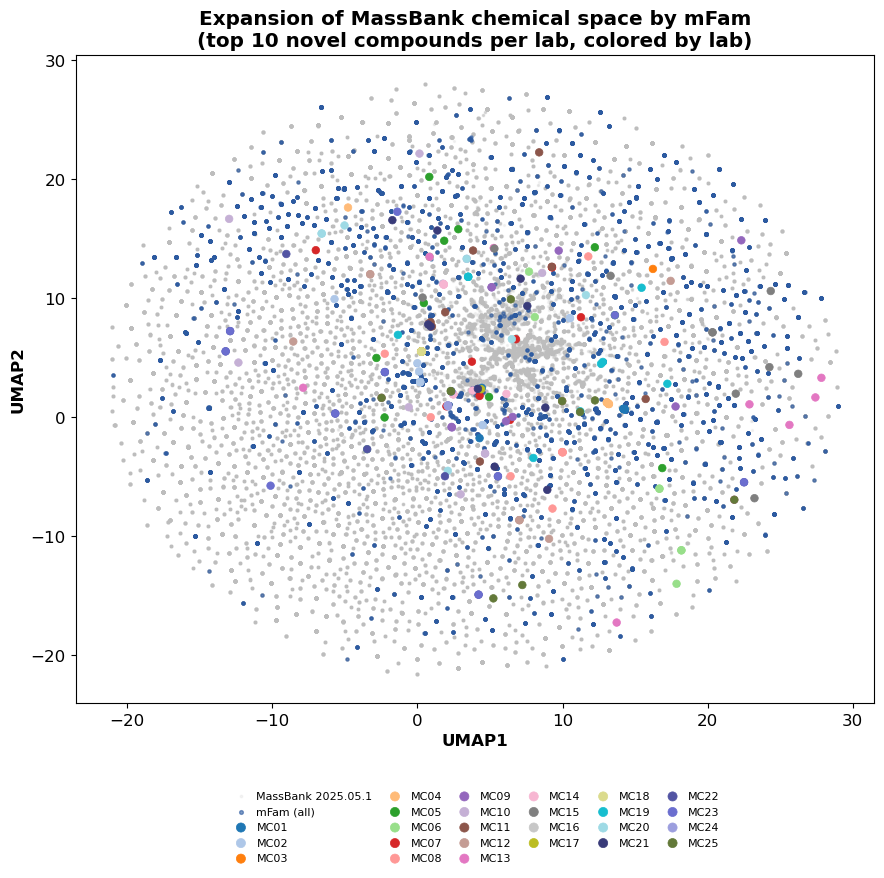

Saved: ./../results/Fig3a_UMAP.png


In [22]:
# Panel (a): UMAP — mFam highlights colored by lab
old_plot = df_valid[df_valid["source"] == "MassBank_2025.05.1"]
mf_plot  = df_valid[df_valid["source"] == "mFam"]

labs = sorted(highlight["lab"].unique())
n_labs = len(labs)

# Build a color palette for up to 25 labs using two tab10 cycles
import matplotlib.colors as mcolors
tab20_colors = [plt.cm.tab20(i) for i in range(20)]
tab20b_colors = [plt.cm.tab20b(i) for i in range(20)]
combined = tab20_colors + tab20b_colors  # 40 distinct colors
lab_colors = {lab: combined[i % len(combined)] for i, lab in enumerate(labs)}

fig, ax = plt.subplots(figsize=(9, 9))

ax.scatter(old_plot["UMAP1"], old_plot["UMAP2"],
           s=2, alpha=0.15, c=COL_BASELINE, label="MassBank 2025.05.1", zorder=1)

ax.scatter(mf_plot["UMAP1"], mf_plot["UMAP2"],
           s=5, alpha=0.6, c=COL_MFAM, label="mFam (all)", zorder=2)

# Highlighted points per lab
for lab in labs:
    grp = highlight[highlight["lab"] == lab]
    ax.scatter(grp["UMAP1"], grp["UMAP2"],
               s=30, c=[lab_colors[lab]] * len(grp),
               linewidths=0.5, zorder=10, label=lab)

ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title(f"Expansion of MassBank chemical space by mFam\n(top {TOP_N_PER_LAB} novel compounds per lab, colored by lab)")
ax.legend(frameon=False, ncol=6, fontsize=8, markerscale=1.2,
          loc="upper center", bbox_to_anchor=(0.5, -0.12),
          columnspacing=1.0, handletextpad=0.4)

plt.tight_layout()
#plt.savefig(OUT_FIG3A, dpi=300, bbox_inches="tight")
plt.savefig("figure3a.svg", format="svg", bbox_inches="tight")
plt.show()

print("Saved:", OUT_FIG3A)


## Panel (b): Similarity distribution (exclude near-identical matches)

We show the distribution for mFam after excluding entries with similarity ≥ 0.99 to MassBank.


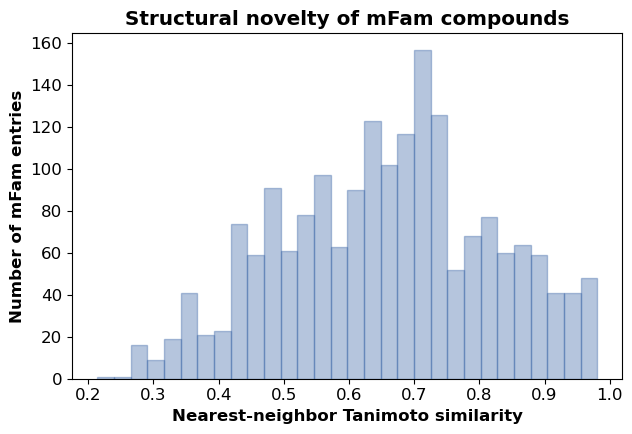

Saved: ./../results/Fig3b_similarity_hist.png


In [23]:
vals = mf_plot.loc[mf_plot["max_sim_to_old"] < NEAR_IDENTICAL_THRESHOLD, "max_sim_to_old"].astype(float)

plt.figure(figsize=(6.5,4.5))
plt.hist(vals, bins=30, color=COL_MFAM, alpha=0.35, edgecolor=COL_MFAM)
plt.xlabel("Nearest-neighbor Tanimoto similarity")
plt.ylabel("Number of mFam entries")
plt.title("Structural novelty of mFam compounds")
plt.tight_layout()
#plt.savefig(OUT_FIG3B, dpi=300)
plt.savefig("figure3b.svg", format="svg", bbox_inches="tight")
plt.show()

print("Saved:", OUT_FIG3B)


## Panel (c): Top-N most novel structures (deduplicated)

We display the chemical structures for the top-N most structurally distinct mFam compounds (unique `smiles_norm`).


In [11]:
from rdkit.Chem import Draw

def save_grid_svg(mols, legends, out_svg, mols_per_row=4, sub_size=(280, 220)):
    svg = Draw.MolsToGridImage(
        mols,
        molsPerRow=mols_per_row,
        subImgSize=sub_size,
        legends=legends,
        useSVG=True
    )
    # Depending on RDKit, svg may be a string or an SVG object
    svg_text = svg if isinstance(svg, str) else svg.data
    with open(out_svg, "w", encoding="utf-8") as f:
        f.write(svg_text)
        

In [13]:
# Panel (c): top-4 structures from the top-5 most novel labs
# "Top labs" = labs with lowest mean max_sim_to_old across their top-10 highlighted compounds
from rdkit.Chem import Draw

lab_novelty = (
    highlight.groupby("lab")["max_sim_to_old"]
    .mean()
    .sort_values(ascending=True)
)
top_labs = lab_novelty.head(TOP_N_LABS).index.tolist()
print("Top labs by novelty (mean sim of top-10 highlights):")
print(lab_novelty.head(TOP_N_LABS).to_string())

fig3c_rows = []
for lab in top_labs:
    lab_rows = (
        highlight[highlight["lab"] == lab]
        .sort_values("max_sim_to_old", ascending=True)
        .head(TOP_N_PER_LAB_FIG3C)
    )
    fig3c_rows.append(lab_rows)

fig3c_df = pd.concat(fig3c_rows, ignore_index=True)

def make_legend(row):
    name = row.get("name", "")
    if isinstance(name, str) and name:
        label = (name[:30] + "…") if len(name) > 30 else name
    else:
        label = row["accession"]
    return f"{row['lab']}: {label}\nsim={row['max_sim_to_old']:.3f}"

mols    = [Chem.MolFromSmiles(s) for s in fig3c_df["smiles_norm"]]
legends = [make_legend(row) for _, row in fig3c_df.iterrows()]

# PNG version
img = Draw.MolsToGridImage(
    mols,
    molsPerRow=TOP_N_PER_LAB_FIG3C,
    subImgSize=(300, 240),
    legends=legends
)
#img.save(OUT_FIG3C_PNG)
print("Saved:", OUT_FIG3C_PNG)
print(f"Grid: {len(top_labs)} labs × {TOP_N_PER_LAB_FIG3C} structures = {len(fig3c_df)} panels")


In [21]:
save_grid_svg(mols, legends, OUT_FIG3C_SVG, mols_per_row=TOP_N_PER_LAB_FIG3C, sub_size=(300, 240))

print("Saved:", OUT_FIG3C_SVG)

Saved: ./../results/Fig3c_topN_structures.svg
